# Customer Ticket Router

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/ai-agent-workshop/ticket-router/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=ai-agent-workshop/ticket-router/demo.ipynb)

An agent that routes inbound support tickets to the right team — and knows when **not** to guess.

**What this notebook covers:**
1. Weighted keyword classification (subject counts 2x body)
2. Routing a sample inbox across 5 teams
3. The low-confidence → human-triage escape hatch
4. Visualizing routing distribution and confidence
5. A "Try Your Own" section for your own tickets


## Step 1: Why tickets get misrouted

Most routing failures aren't "wrong keyword," they're **overconfidence** — a rule fires on a weak
signal and sends a ticket to the wrong team anyway. This agent scores every team, weights subject
matches higher than body matches, and if no team clears a confidence threshold, routes to
**human-triage** instead of guessing.


In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field
from typing import Dict, List, Optional


@dataclass
class Ticket:
    ticket_id: str
    subject: str
    body: str


@dataclass
class RouteResult:
    ticket_id: str
    team: str
    confidence: float
    reasoning: str
    matched_keywords: List[str] = field(default_factory=list)


TEAM_KEYWORDS: Dict[str, List[str]] = {
    "billing": ["invoice", "charge", "refund", "payment", "subscription", "billing", "credit card", "receipt", "overcharged"],
    "technical": ["error", "bug", "crash", "not working", "broken", "timeout", "login failed", "500", "exception", "outage"],
    "account": ["password", "reset", "locked out", "email change", "delete account", "username", "two-factor", "profile"],
    "sales": ["pricing", "upgrade", "demo", "quote", "enterprise plan", "trial", "discount", "renew contract"],
}

DEFAULT_TEAM = "general"


def _keyword_score(text: str, keywords: List[str]) -> List[str]:
    text_lower = text.lower()
    return [kw for kw in keywords if kw in text_lower]


def _rule_based_route(subject: str, body: str):
    best_team, best_score, best_matches = DEFAULT_TEAM, 0.0, []
    for team, keywords in TEAM_KEYWORDS.items():
        subject_matches = _keyword_score(subject, keywords)
        body_matches = _keyword_score(body, keywords)
        all_matches = list(dict.fromkeys(subject_matches + body_matches))
        score = len(subject_matches) * 2 + len(body_matches)
        if score > best_score:
            best_score, best_team, best_matches = score, team, all_matches

    total_possible = max(len(TEAM_KEYWORDS.get(best_team, [])), 1)
    confidence = min(best_score / (total_possible * 1.5), 1.0) if best_score > 0 else 0.2
    return best_team, round(confidence, 2), best_matches


def route_ticket(ticket: Ticket, low_confidence_threshold: float = 0.35) -> RouteResult:
    team, confidence, matched = _rule_based_route(ticket.subject, ticket.body)
    reasoning = f"matched keywords: {', '.join(matched)}" if matched else "no strong keyword match, defaulting to general queue"
    if confidence < low_confidence_threshold:
        return RouteResult(ticket.ticket_id, "human-triage", confidence, f"low confidence ({confidence}), needs human review — {reasoning}", matched)
    return RouteResult(ticket.ticket_id, team, confidence, reasoning, matched)


def route_batch(tickets: List[Ticket], low_confidence_threshold: float = 0.35) -> List[RouteResult]:
    return [route_ticket(t, low_confidence_threshold) for t in tickets]

print("Router loaded.")

Router loaded.


## Step 2: Route a sample inbox

Five tickets spanning billing, technical, account, sales — and one genuinely ambiguous one.

In [2]:
sample_tickets = [
    Ticket("T1", "Overcharged on my invoice", "I was charged twice for my subscription this month, please refund."),
    Ticket("T2", "Getting a 500 error on login", "App keeps crashing with a 500 error every time I try to log in, this is broken."),
    Ticket("T3", "Forgot my password", "I got locked out of my account and need a password reset."),
    Ticket("T4", "Interested in enterprise plan", "Can I get a quote for the enterprise plan and a demo?"),
    Ticket("T5", "Hello", "just checking in, no specific issue"),
]

results = route_batch(sample_tickets)
for r in results:
    print(f"{r.ticket_id}  ->  {r.team:14s} ({r.confidence:.0%})  |  {r.reasoning}")

T1  ->  billing        (67%)  |  matched keywords: invoice, charge, overcharged, refund, subscription
T2  ->  technical      (53%)  |  matched keywords: error, 500, crash, broken
T3  ->  account        (42%)  |  matched keywords: password, reset, locked out
T4  ->  sales          (42%)  |  matched keywords: enterprise plan, demo, quote
T5  ->  human-triage   (20%)  |  low confidence (0.2), needs human review — no strong keyword match, defaulting to general queue


## Visualization: routing distribution and confidence

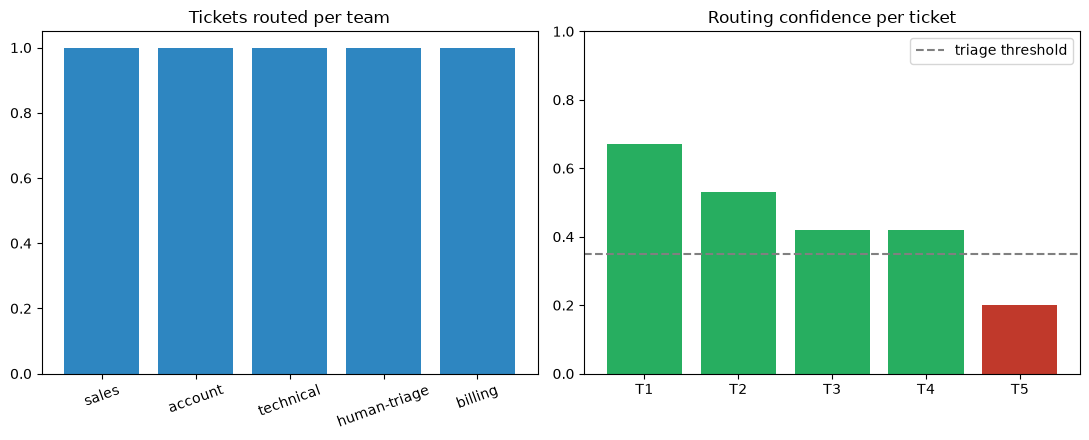

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

teams = [r.team for r in results]
team_counts = {t: teams.count(t) for t in set(teams)}
axes[0].bar(team_counts.keys(), team_counts.values(), color="#2E86C1")
axes[0].set_title("Tickets routed per team")
axes[0].tick_params(axis="x", rotation=20)

ids = [r.ticket_id for r in results]
confidences = [r.confidence for r in results]
colors = ["#C0392B" if r.team == "human-triage" else "#27AE60" for r in results]
axes[1].bar(ids, confidences, color=colors)
axes[1].axhline(0.35, color="gray", linestyle="--", label="triage threshold")
axes[1].set_title("Routing confidence per ticket")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.savefig("routing_results.png", dpi=150)
plt.show()

## Summary

4 of 5 tickets routed with clear signal. T5 ("just checking in") had no keyword match and correctly
fell to `human-triage` instead of being force-fit into a team — the whole point of a confidence
threshold. This is what prevents the "40% wrong team" failure mode: a wrong-but-confident guess is
worse than an honest "I'm not sure."


## Try Your Own

Uncomment and edit to route your own ticket:

In [4]:
# my_ticket = Ticket("T99", "Your subject here", "Your ticket body here.")
# my_result = route_ticket(my_ticket)
# print(my_result.team, my_result.confidence, my_result.reasoning)

---
**[← Back to portfolio](../../README.md)**

For the interactive version with a UI:
```bash
pip install -r requirements.txt
streamlit run app.py
```
Set `ANTHROPIC_API_KEY` to swap the keyword classifier for Claude-based classification.
